In [ ]:
%pip install scikit-learn numpy matplotlib tensorflow

50 acurácia antes do treinamento
0 16.878178733560723
1000 4.271647738507798
2000 4.267521126568985
3000 4.266478363190809
4000 4.266289594351347
5000 4.26570171474131
6000 4.265706094048394
7000 4.265619202966087
8000 4.265552925605364
9000 4.265454341307981
acc 86
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8900 - loss: 0.0758 


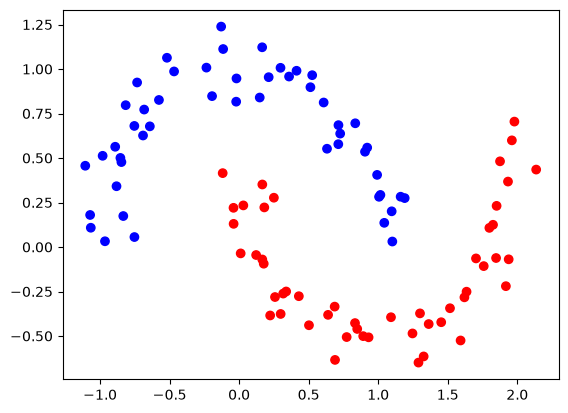

In [ ]:
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD
from keras import initializers

X, Y = datasets.make_moons(100, noise=0.1)

color = ['blue' if k == 0 else 'red' for k in Y]

plt.scatter(X[:, 0], X[:, 1], c=color)
plt.savefig('duas_luas.svg')


def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def run_neural_net(x, w0, b0, b1, w1):
    s00 = w0[0, 0] * x[0]
    s01 = w0[0, 1] * x[1]
    s02 = s00 + s01
    v0 = s02 + b0[0]
    y0 = relu(v0)

    s10 = w0[1, 0] * x[0]
    s11 = w0[1, 1] * x[1]
    s12 = s10 + s11
    v1 = s12 + b0[1]
    y1 = relu(v1)

    s20 = w0[2, 0] * x[0]
    s21 = w0[2, 1] * x[1]
    s22 = s20 + s21
    v2 = s22 + b0[2]
    y2 = relu(v2)

    s30 = w0[3, 0] * x[0]
    s31 = w0[3, 1] * x[1]
    s32 = s30 + s31
    v3 = s32 + b0[3]
    y3 = relu(v3)

    s40 = y0 * w1[0]
    s41 = y1 * w1[1]
    s42 = y2 * w1[2]
    s43 = y3 * w1[3]
    s44 = s40 + s41 + s42 + s43
    v4 = s44 + b1[0]
    y4 = sigmoid(v4)

    return 1 if y4 > 0.5 else 0

def neural_net(x, d, w0, b0, b1, w1):
    # forward

    s00 = w0[0, 0] * x[0]
    s01 = w0[0, 1] * x[1]
    s02 = s00 + s01
    v0 = s02 + b0[0]
    y0 = relu(v0)

    s10 = w0[1, 0] * x[0]
    s11 = w0[1, 1] * x[1]
    s12 = s10 + s11
    v1 = s12 + b0[1]
    y1 = relu(v1)

    s20 = w0[2, 0] * x[0]
    s21 = w0[2, 1] * x[1]
    s22 = s20 + s21
    v2 = s22 + b0[2]
    y2 = relu(v2)

    s30 = w0[3, 0] * x[0]
    s31 = w0[3, 1] * x[1]
    s32 = s30 + s31
    v3 = s32 + b0[3]
    y3 = relu(v3)

    s40 = y0 * w1[0]
    s41 = y1 * w1[1]
    s42 = y2 * w1[2]
    s43 = y3 * w1[3]
    s44 = s40 + s41 + s42 + s43
    v4 = s44 + b1[0]
    y4 = sigmoid(v4)

    e = y4 - d
    L = 1/2 * (e ** 2)


    # backward
    grad_w0 = np.zeros(w0.shape)
    grad_w1 = np.zeros(w1.shape)
    grad_b0 = np.zeros(b0.shape)
    grad_b1 = np.zeros(b1.shape)

    grad_L = 1
    grad_e = grad_L * e

    grad_y4 = grad_e
    grad_v4 = grad_y4 * y4 * (1 - y4)
    grad_b1[0] = grad_v4

    grad_s44 = grad_v4
    grad_s40 = grad_s44
    grad_s41 = grad_s44
    grad_s42 = grad_s44
    grad_s43 = grad_s44

    grad_w1[0] = grad_s40 * y0
    grad_w1[1] = grad_s41 * y1
    grad_w1[2] = grad_s42 * y2
    grad_w1[3] = grad_s43 * y3

    grad_y0 = grad_s40 * w1[0]
    grad_y1 = grad_s41 * w1[1]
    grad_y2 = grad_s42 * w1[2]
    grad_y3 = grad_s43 * w1[3]

    grad_v0 = grad_y0 * (1 if v0 > 0 else 0)
    grad_v1 = grad_y1 * (1 if v1 > 0 else 0)
    grad_v2 = grad_y2 * (1 if v2 > 0 else 0)
    grad_v3 = grad_y3 * (1 if v3 > 0 else 0)

    grad_b0[0] = grad_v0
    grad_b0[1] = grad_v1
    grad_b0[2] = grad_v2
    grad_b0[3] = grad_v3

    grad_s02 = grad_v0
    grad_s12 = grad_v1
    grad_s22 = grad_v2
    grad_s32 = grad_v3

    grad_s00 = grad_s02
    grad_s01 = grad_s02
    grad_s10 = grad_s12
    grad_s11 = grad_s12
    grad_s20 = grad_s22
    grad_s21 = grad_s22
    grad_s30 = grad_s32
    grad_s31 = grad_s32

    grad_w0[0, 0] = grad_s00 * x[0]
    grad_w0[0, 1] = grad_s01 * x[1]
    grad_w0[1, 0] = grad_s10 * x[0]
    grad_w0[1, 1] = grad_s11 * x[1]
    grad_w0[2, 0] = grad_s20 * x[0]
    grad_w0[2, 1] = grad_s21 * x[1]
    grad_w0[3, 0] = grad_s30 * x[0]
    grad_w0[3, 1] = grad_s31 * x[1]

    return grad_w0, grad_b0, grad_w1, grad_b1, L

def main():
    # inicialização aleatória
    w0 = np.random.rand(4, 2)
    w1 = np.random.rand(4)
    b0 = np.random.rand(4)
    b1 = np.random.rand(1)

    # taxa de aprendizado
    taxa = 0.1

    acc = 0
    for i in range(100):
        out = run_neural_net(X[i], w0, b0, b1, w1)
        if out == Y[i]:
            acc += 1
    print(acc, "acurácia antes do treinamento")

    # gradiente descendente
    for i in range(10000):
        loss = 0

        grad_w0 = np.zeros(w0.shape)
        grad_w1 = np.zeros(w1.shape)
        grad_b0 = np.zeros(b0.shape)
        grad_b1 = np.zeros(b1.shape)

        for k in range(100):
            g_w0, g_b0, g_w1, g_b1, L = neural_net(X[k], Y[k], w0, b0, b1, w1)

            grad_w0 += g_w0
            grad_w1 += g_w1
            grad_b0 += g_b0
            grad_b1 += g_b1
            loss += L

        w0 -= taxa * grad_w0
        w1 -= taxa * grad_w1
        b0 -= taxa * grad_b0
        b1 -= taxa * grad_b1

        if i % 1000 == 0:
            print(i, loss)

    # acurácia após o treinamento
    acc = 0
    for i in range(100):
        out = run_neural_net(X[i],  w0, b0, b1, w1)
        if out == Y[i]:
            acc += 1
    print('acc', acc)

    model = Sequential()
    model.add(Dense(4, input_dim=2, activation='relu'))  # Igual à rede manual
    model.add(Dense(1, activation='sigmoid'))
    
    opt = SGD(learning_rate=taxa)
    model.compile(loss='mean_squared_error', optimizer=opt, metrics=['accuracy'])
    model.fit(X, Y, epochs=100, verbose=False, batch_size=5)

    acc = model.evaluate(X, Y)


main()